In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all columns
pd.set_option('display.max_columns', None)


In [20]:
# Load the dataset
df = pd.read_csv('Auto Sales data.csv')

# Preview the data
df.head()


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,24/02/2018,828,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,07/05/2018,757,Shipped,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,01/07/2018,703,Shipped,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,25/08/2018,649,Shipped,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium
4,10168,36,96.66,1,3479.76,28/10/2018,586,Shipped,Motorcycles,95,S10_1678,Technics Stores Inc.,6505556809,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium


In [21]:
# Dataset info
df.info()

# Summary statistics
df.describe()

# Check for missing values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2747 entries, 0 to 2746
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ORDERNUMBER           2747 non-null   int64  
 1   QUANTITYORDERED       2747 non-null   int64  
 2   PRICEEACH             2747 non-null   float64
 3   ORDERLINENUMBER       2747 non-null   int64  
 4   SALES                 2747 non-null   float64
 5   ORDERDATE             2747 non-null   object 
 6   DAYS_SINCE_LASTORDER  2747 non-null   int64  
 7   STATUS                2747 non-null   object 
 8   PRODUCTLINE           2747 non-null   object 
 9   MSRP                  2747 non-null   int64  
 10  PRODUCTCODE           2747 non-null   object 
 11  CUSTOMERNAME          2747 non-null   object 
 12  PHONE                 2747 non-null   object 
 13  ADDRESSLINE1          2747 non-null   object 
 14  CITY                  2747 non-null   object 
 15  POSTALCODE           

ORDERNUMBER             0
QUANTITYORDERED         0
PRICEEACH               0
ORDERLINENUMBER         0
SALES                   0
ORDERDATE               0
DAYS_SINCE_LASTORDER    0
STATUS                  0
PRODUCTLINE             0
MSRP                    0
PRODUCTCODE             0
CUSTOMERNAME            0
PHONE                   0
ADDRESSLINE1            0
CITY                    0
POSTALCODE              0
COUNTRY                 0
CONTACTLASTNAME         0
CONTACTFIRSTNAME        0
DEALSIZE                0
dtype: int64

In [22]:
# Convert ORDERDATE to datetime
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], dayfirst=True)


In [23]:
# Unique product lines
print("Product Lines:", df['PRODUCTLINE'].unique())

# Status distribution
print("Order Statuses:\n", df['STATUS'].value_counts())

# Country-wise customer count
print("Customers by Country:\n", df['COUNTRY'].value_counts())


Product Lines: ['Motorcycles' 'Classic Cars' 'Trucks and Buses' 'Vintage Cars' 'Planes'
 'Ships' 'Trains']
Order Statuses:
 STATUS
Shipped       2541
Cancelled       60
Resolved        47
On Hold         44
In Process      41
Disputed        14
Name: count, dtype: int64
Customers by Country:
 COUNTRY
USA            928
Spain          342
France         314
Australia      185
UK             144
Italy          113
Finland         92
Norway          85
Singapore       79
Canada          70
Denmark         63
Germany         62
Sweden          57
Austria         55
Japan           52
Belgium         33
Switzerland     31
Philippines     26
Ireland         16
Name: count, dtype: int64


# Objective 1: Sales Trend Analysis

In [24]:
# Create Year and Month columns
df['YEAR'] = df['ORDERDATE'].dt.year
df['MONTH'] = df['ORDERDATE'].dt.month
df['MONTH_NAME'] = df['ORDERDATE'].dt.strftime('%B')


In [25]:
# Group by Year and Month for total sales
monthly_sales = df.groupby(['YEAR', 'MONTH_NAME'])['SALES'].sum().reset_index()

# To maintain calendar order
from pandas.api.types import CategoricalDtype
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
month_type = CategoricalDtype(categories=month_order, ordered=True)
monthly_sales['MONTH_NAME'] = monthly_sales['MONTH_NAME'].astype(month_type)

# Sort for proper plotting
monthly_sales = monthly_sales.sort_values(['YEAR', 'MONTH_NAME'])


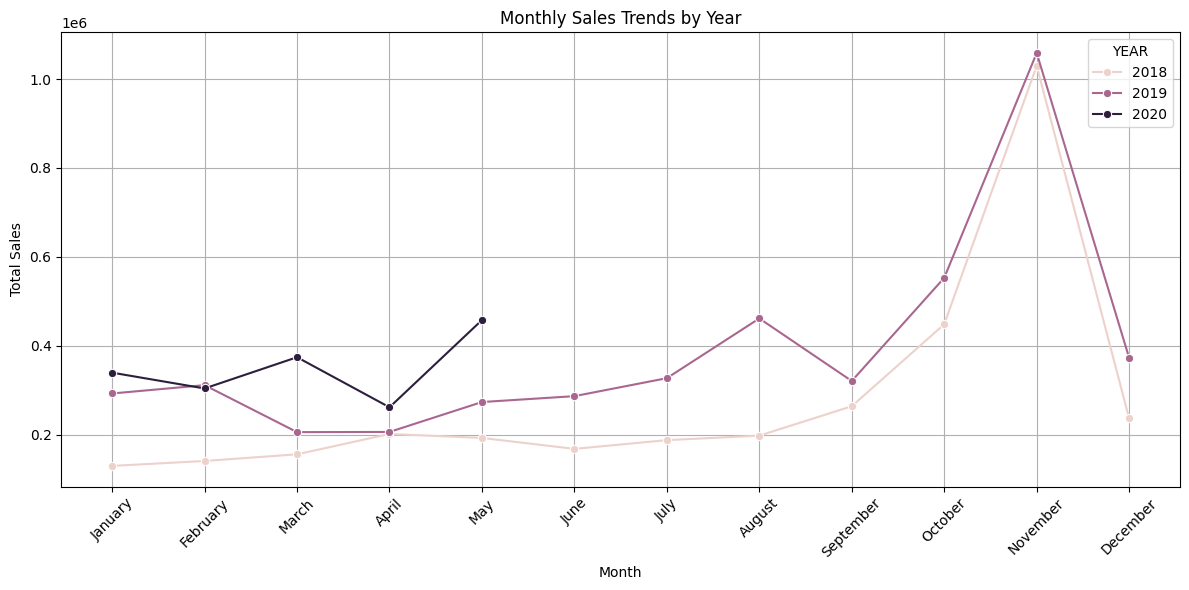

In [26]:
#Plot Monthly Sales Trends
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='MONTH_NAME', y='SALES', hue='YEAR', marker='o')
plt.title('Monthly Sales Trends by Year')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\guard\AppData\Local\Temp\ipykernel_5940\2503783288.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_sales, x='YEAR', y='SALES', palette='viridis')


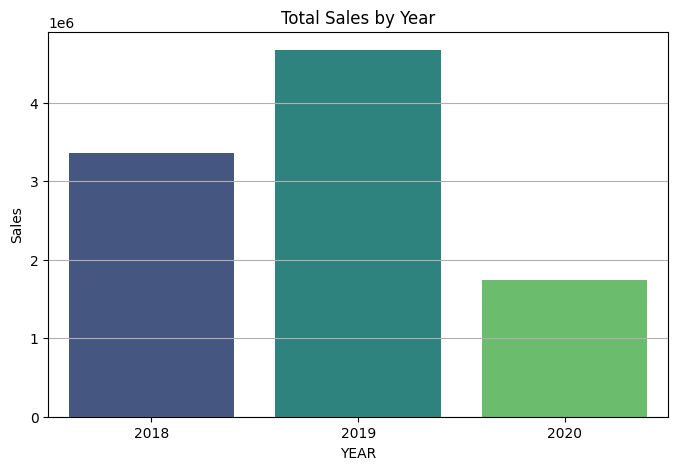

In [27]:
# Total sales by year
yearly_sales = df.groupby('YEAR')['SALES'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=yearly_sales, x='YEAR', y='SALES', palette='viridis')
plt.title('Total Sales by Year')
plt.ylabel('Sales')
plt.grid(True, axis='y')
plt.show()


# Objective 2: Product and Category Performance

C:\Users\guard\AppData\Local\Temp\ipykernel_5940\445078396.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=productline_sales, x='SALES', y='PRODUCTLINE', palette='coolwarm')


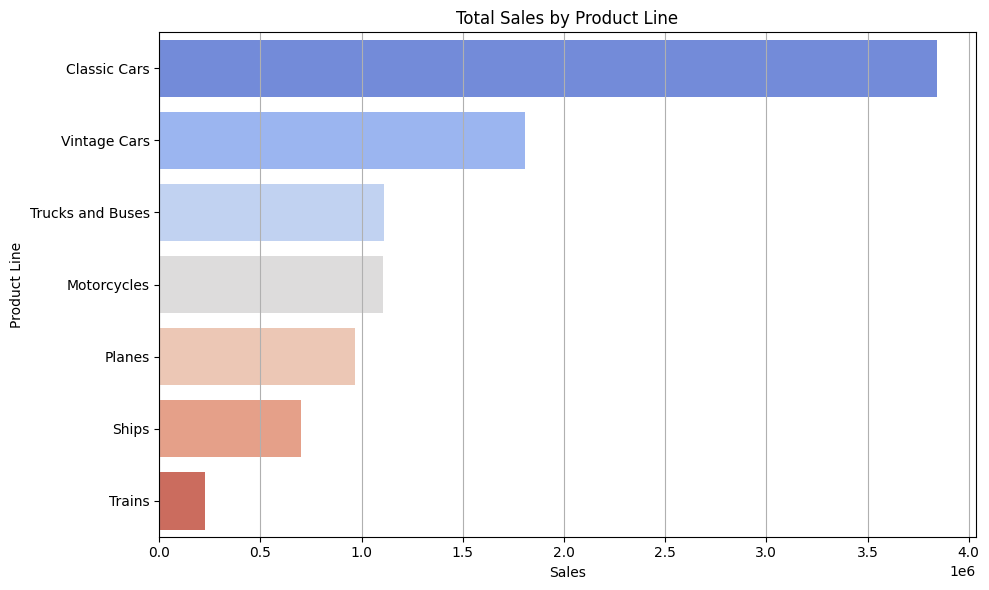

In [28]:
# Total Sales by Product Line
productline_sales = df.groupby('PRODUCTLINE')['SALES'].sum().reset_index().sort_values(by='SALES', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=productline_sales, x='SALES', y='PRODUCTLINE', palette='coolwarm')
plt.title('Total Sales by Product Line')
plt.xlabel('Sales')
plt.ylabel('Product Line')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


In [29]:
# Average Price and Quantity by Product Line
productline_stats = df.groupby('PRODUCTLINE').agg({
    'PRICEEACH': 'mean',
    'QUANTITYORDERED': 'mean',
    'SALES': 'mean'
}).reset_index()

print(productline_stats)


        PRODUCTLINE   PRICEEACH  QUANTITYORDERED        SALES
0      Classic Cars  115.195680        35.166491  4049.387292
1       Motorcycles   99.767125        35.399361  3525.598051
2            Planes   90.517829        34.986842  3188.563882
3             Ships   88.169261        34.734783  3043.648783
4            Trains   84.108701        35.220779  2938.226883
5  Trucks and Buses  104.344983        35.861017  3767.997254
6      Vintage Cars   90.011261        34.644214  3120.337962


C:\Users\guard\AppData\Local\Temp\ipykernel_5940\14660599.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='SALES', y='PRODUCTCODE', palette='magma')


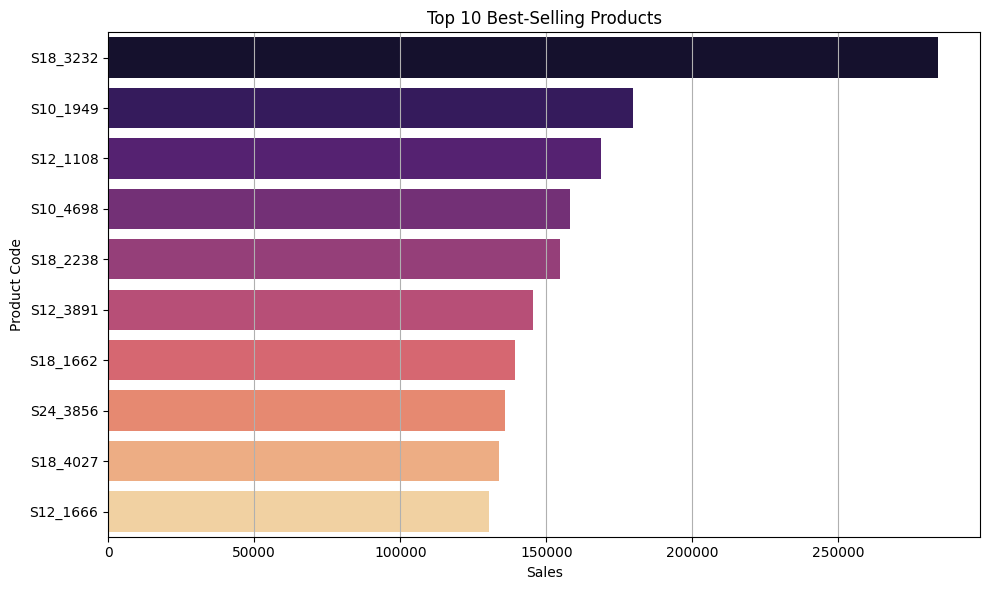

In [30]:
# Top 10 Best-Selling Products (by SALES)
top_products = df.groupby('PRODUCTCODE')['SALES'].sum().reset_index().sort_values(by='SALES', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='SALES', y='PRODUCTCODE', palette='magma')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Sales')
plt.ylabel('Product Code')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


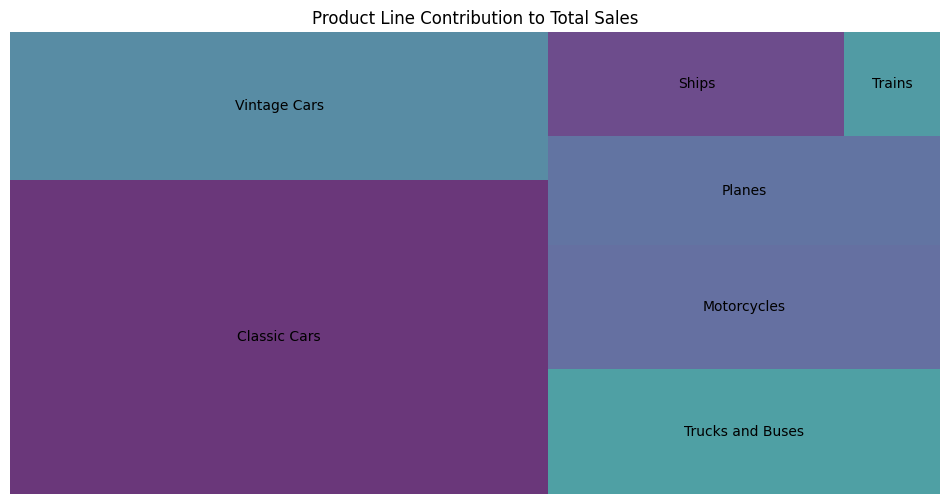

In [31]:
# Treemap of Product Line Contribution
# If not installed: !pip install squarify
import squarify

plt.figure(figsize=(12, 6))
squarify.plot(sizes=productline_sales['SALES'], label=productline_sales['PRODUCTLINE'], alpha=.8)
plt.title('Product Line Contribution to Total Sales')
plt.axis('off')
plt.show()


# Objective 3: Customer Segmentation and Behavior

C:\Users\guard\AppData\Local\Temp\ipykernel_5940\3123431038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_stats.head(10), x='SALES', y='COUNTRY', palette='crest')


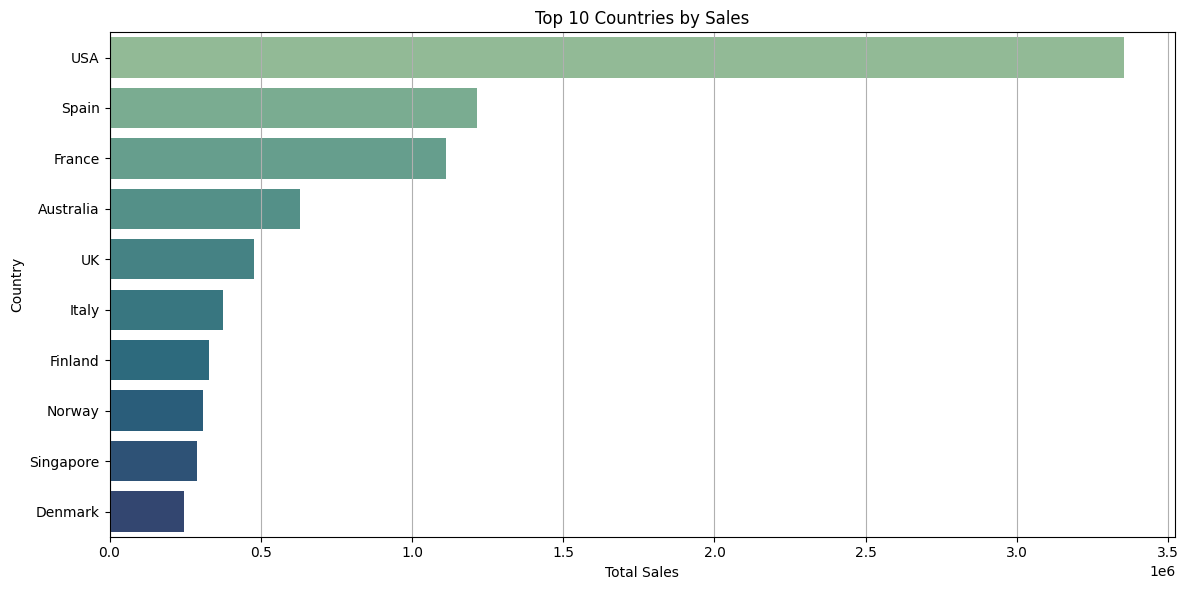

,COUNTRY,UNIQUE_CUSTOMERS,SALES
0,USA,32,3355575.69
1,Spain,5,1215686.92
2,France,12,1110916.52
3,Australia,5,630623.10
4,UK,5,478880.46


In [32]:
# Customer Count and Sales by Country
country_stats = df.groupby('COUNTRY').agg({
    'CUSTOMERNAME': 'nunique',
    'SALES': 'sum'
}).rename(columns={'CUSTOMERNAME': 'UNIQUE_CUSTOMERS'}).sort_values(by='SALES', ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=country_stats.head(10), x='SALES', y='COUNTRY', palette='crest')
plt.title('Top 10 Countries by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Country')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

country_stats.head()


C:\Users\guard\AppData\Local\Temp\ipykernel_5940\1314672696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_customers, x='SALES', y='CUSTOMERNAME', palette='flare')


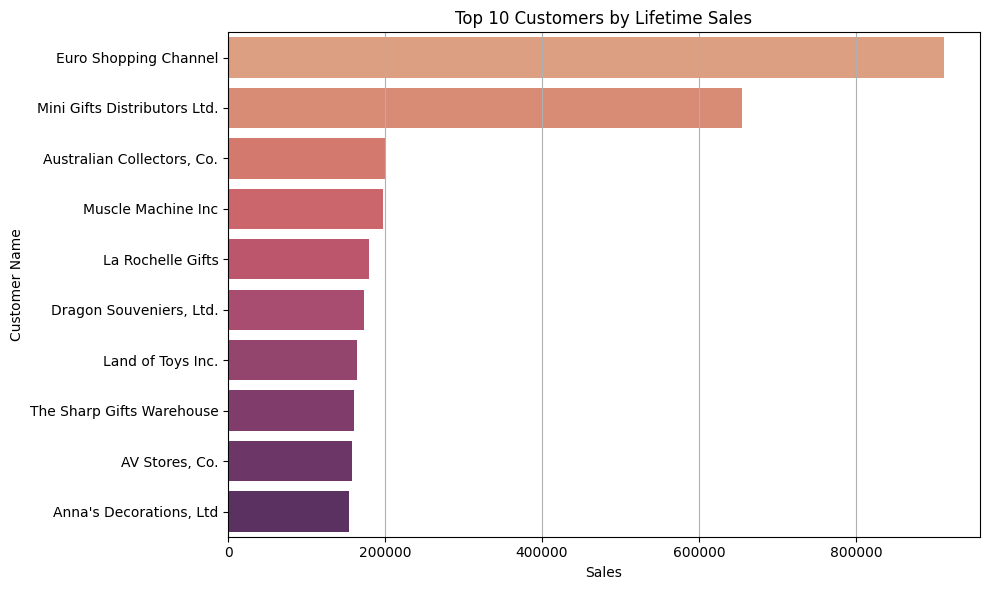

In [33]:
top_customers = df.groupby('CUSTOMERNAME')['SALES'].sum().reset_index().sort_values(by='SALES', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_customers, x='SALES', y='CUSTOMERNAME', palette='flare')
plt.title('Top 10 Customers by Lifetime Sales')
plt.xlabel('Sales')
plt.ylabel('Customer Name')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


C:\Users\guard\AppData\Local\Temp\ipykernel_5940\3922947007.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='DEALSIZE', palette='Set2', order=df['DEALSIZE'].value_counts().index)


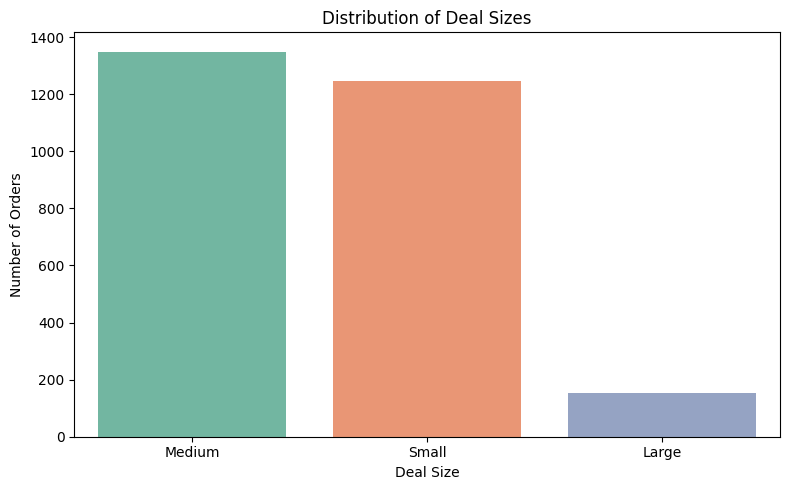

In [34]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='DEALSIZE', palette='Set2', order=df['DEALSIZE'].value_counts().index)
plt.title('Distribution of Deal Sizes')
plt.xlabel('Deal Size')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


C:\Users\guard\AppData\Local\Temp\ipykernel_5940\1703139726.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dealsize_sales, x='DEALSIZE', y='SALES', palette='Set1')


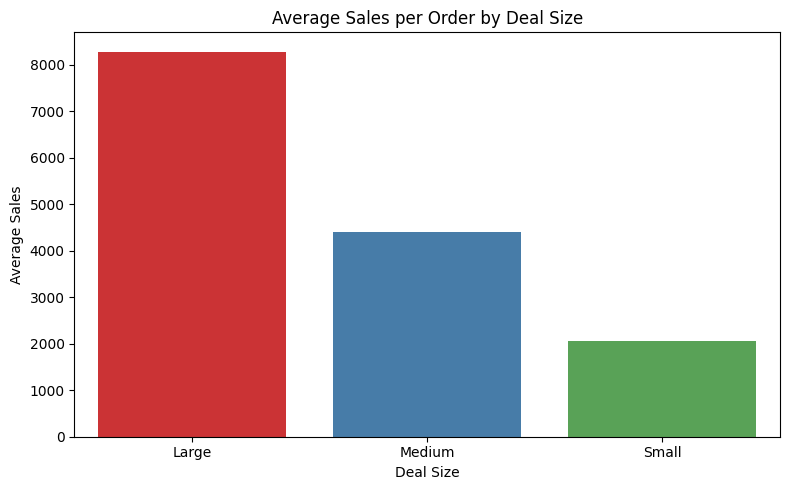

In [35]:
dealsize_sales = df.groupby('DEALSIZE')['SALES'].mean().reset_index().sort_values(by='SALES', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=dealsize_sales, x='DEALSIZE', y='SALES', palette='Set1')
plt.title('Average Sales per Order by Deal Size')
plt.xlabel('Deal Size')
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()


# Objective 4: Pricing Strategy and Discount Impact

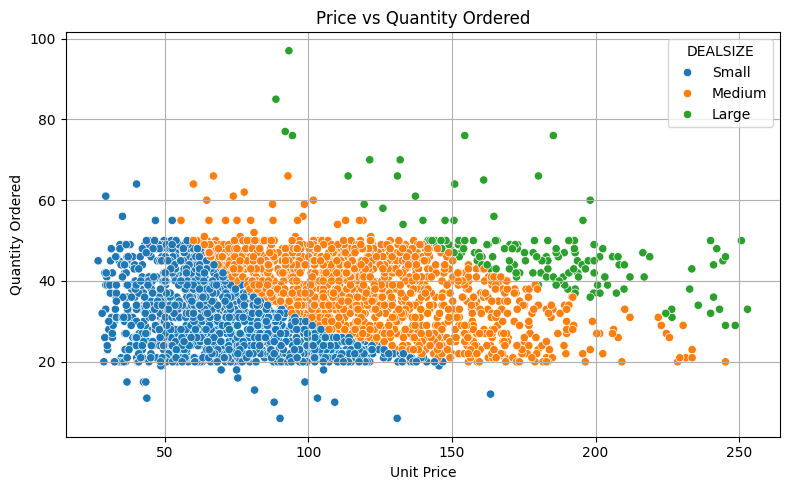

In [36]:
# Relationship Between Price and Quantity Ordered
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='PRICEEACH', y='QUANTITYORDERED', hue='DEALSIZE')
plt.title('Price vs Quantity Ordered')
plt.xlabel('Unit Price')
plt.ylabel('Quantity Ordered')
plt.grid(True)
plt.tight_layout()
plt.show()


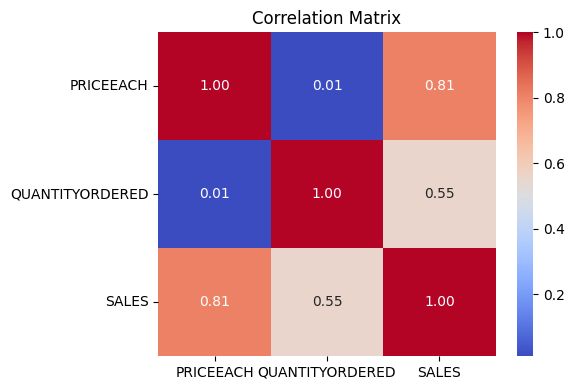

In [38]:
# Correlation Between Key Metrics
# Check correlations
corr = df[['PRICEEACH', 'QUANTITYORDERED', 'SALES']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


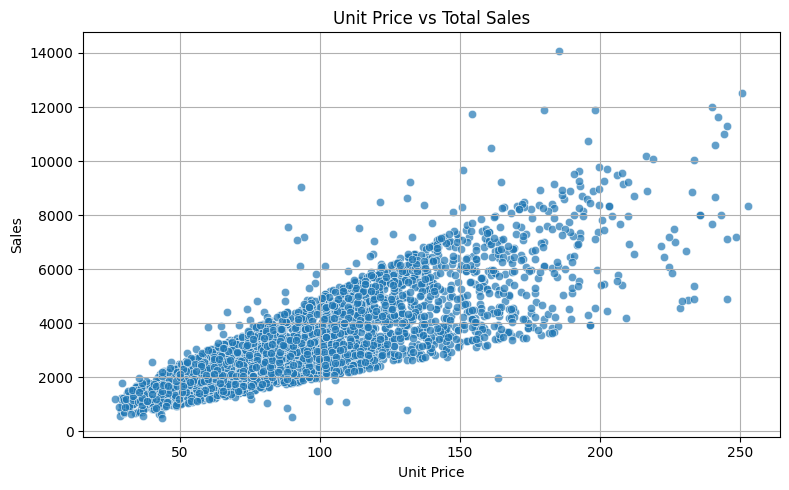

In [39]:
# Price vs Sales per Order
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='PRICEEACH', y='SALES', alpha=0.7)
plt.title('Unit Price vs Total Sales')
plt.xlabel('Unit Price')
plt.ylabel('Sales')
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\guard\AppData\Local\Temp\ipykernel_5940\1445162840.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pricebin_sales = df.groupby('PRICE_BIN')['SALES'].mean().reset_index()
C:\Users\guard\AppData\Local\Temp\ipykernel_5940\1445162840.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pricebin_sales, x='PRICE_BIN', y='SALES', palette='plasma')


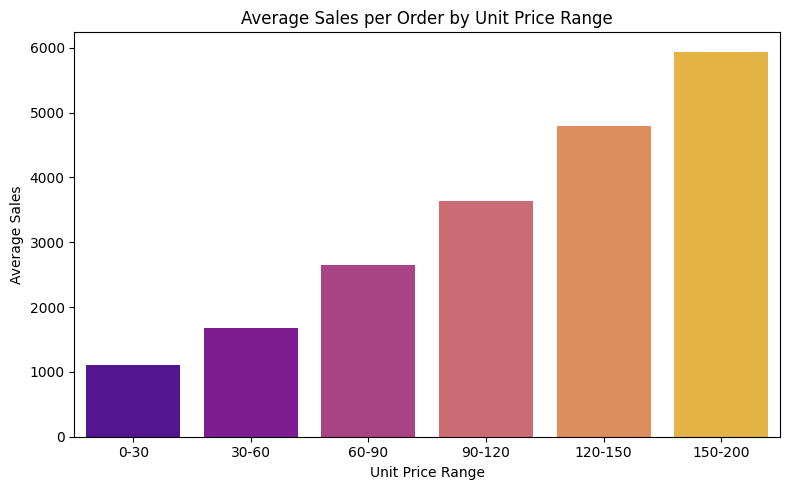

In [40]:
# Average Sales by Price Range
# Create price bins
df['PRICE_BIN'] = pd.cut(df['PRICEEACH'], bins=[0, 30, 60, 90, 120, 150, 200], labels=['0-30','30-60','60-90','90-120','120-150','150-200'])

pricebin_sales = df.groupby('PRICE_BIN')['SALES'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=pricebin_sales, x='PRICE_BIN', y='SALES', palette='plasma')
plt.title('Average Sales per Order by Unit Price Range')
plt.xlabel('Unit Price Range')
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()


# Objective 5: Order Fulfillment and Status Impact

C:\Users\guard\AppData\Local\Temp\ipykernel_5940\3892669116.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status_sales, x='STATUS', y='SALES', palette='Set3')


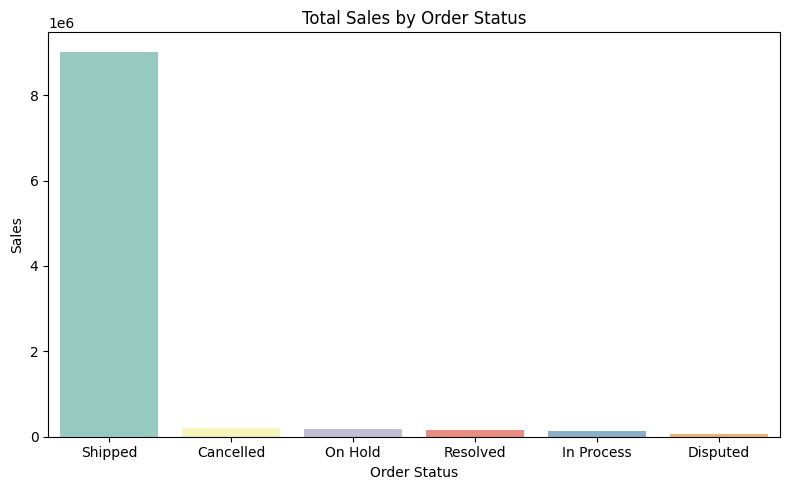

In [41]:
# Sales Breakdown by Order Status
status_sales = df.groupby('STATUS')['SALES'].sum().reset_index().sort_values(by='SALES', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=status_sales, x='STATUS', y='SALES', palette='Set3')
plt.title('Total Sales by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()


C:\Users\guard\AppData\Local\Temp\ipykernel_5940\343288411.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='STATUS', palette='Set2', order=df['STATUS'].value_counts().index)


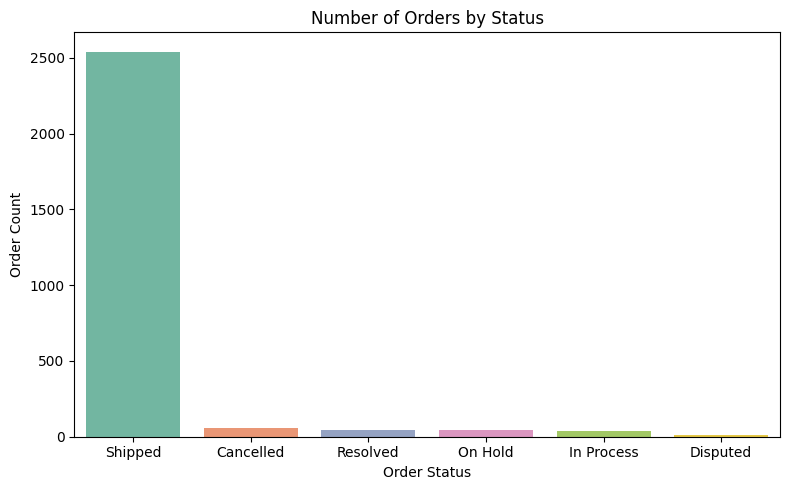

In [42]:
# Order Count by Status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='STATUS', palette='Set2', order=df['STATUS'].value_counts().index)
plt.title('Number of Orders by Status')
plt.xlabel('Order Status')
plt.ylabel('Order Count')
plt.tight_layout()
plt.show()


In [43]:
# Average Sales and Delay (Days Since Last Order) by Status
status_behavior = df.groupby('STATUS')[['SALES', 'DAYS_SINCE_LASTORDER']].mean().reset_index()

print(status_behavior)


       STATUS        SALES  DAYS_SINCE_LASTORDER
0   Cancelled  3241.458000           2049.366667
1    Disputed  5158.061429           1087.642857
2  In Process  3529.999024           1228.000000
3     On Hold  4067.708864           1685.227273
4    Resolved  3206.771915           1829.851064
5     Shipped  3549.426974           1762.308146


In [44]:
# Cancelled Orders Analysis
cancelled = df[df['STATUS'] == 'Cancelled']
print("Number of Cancelled Orders:", cancelled.shape[0])
print("Lost Sales from Cancelled Orders: $", cancelled['SALES'].sum())


Number of Cancelled Orders: 60
Lost Sales from Cancelled Orders: $ 194487.48


##  Summary & Business Recommendations

###  Key Insights

1. **Sales Trends**
   - Sales show clear seasonal trends, with specific months (e.g., November and December) consistently performing better.
   - Year-over-year growth can be evaluated to monitor business progress.

2. **Product & Category Performance**
   - Certain `PRODUCTLINE`s significantly outperform others in total sales.
   - A few specific `PRODUCTCODE`s contribute a large share of revenue, suggesting a product-focused sales strategy could be beneficial.

3. **Customer Segmentation**
   - The majority of revenue comes from a small group of top customers and high-performing countries.
   - Larger deal sizes (e.g., “Large”) are typically associated with higher average order values.

4. **Pricing & Discount Patterns**
   - Lower-priced items tend to be ordered in higher volumes, which might indicate a discount-driven purchase trend.
   - There is moderate correlation between `PRICEEACH`, `QUANTITYORDERED`, and `SALES`, showing that both pricing and volume play key roles.

5. **Order Status Impact**
   - Most sales come from orders with a "Shipped" status, while "Cancelled" orders represent a potential loss in revenue.
   - Understanding customer churn and late/cancelled orders could help improve fulfillment processes.

---

###  Business Recommendations

- **Focus marketing efforts** during peak months and offer promotions during slow months to boost sales consistency.
- **Double down on top-performing product lines** by promoting best-sellers and analyzing what makes them successful.
- **Strengthen relationships with high-value customers** and target similar profiles using geographic and deal size insights.
- **Test price elasticity** by offering discounts on mid-performing products to see if volume increases compensate for lower margins.
- **Reduce order cancellations** by improving logistics, offering better tracking, and following up on delayed orders.
